# Deep learning project by @breezy_yrn
# X-ray Image Classification 

In [1]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [2]:
# Load the Drive helper and mount
#from google.colab import drive
#drive.mount('/content/drive')

In [9]:
# setting the training data directory
DataDir = r"C:\\Users\\Admin\\OneDrive\\Desktop\\deep_project\\chest_xray-20250726T110654Z-1-001\\chest_xray\\train"

In [10]:
# intiallizing the category of classification
CATEGORIES = ["NORMAL", "PNEUMONIA"]

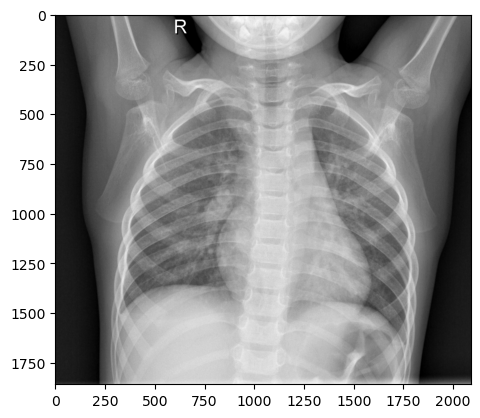

In [11]:
# converting the images into grayscale
for i in CATEGORIES:
    path=os.path.join(DataDir,i)
    for img in os.listdir(path):
        img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
        plt.imshow(img_array,cmap='gray')
        plt.show()
        break
    break

In [12]:
# intializing the size of the image so that every image should be in same dimension
img_size=100

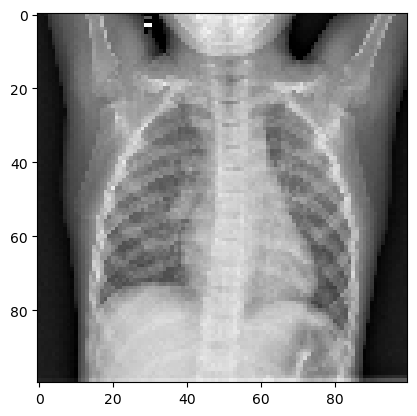

In [13]:
# image after resize and gray scale
new_array=cv2.resize(img_array,(img_size,img_size))
plt.imshow(new_array,cmap='gray')
plt.show()

In [14]:
training_data=[]

In [15]:
# defining the function for training data according to the categories converting the images into gray scale with resizing the image into 100 x 100
# converting it into numpy arrays
def create_training_data():
    for i in CATEGORIES:

        path=os.path.join(DataDir,i)
        class_num=CATEGORIES.index(i)

        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
                new_array=cv2.resize(img_array,(img_size,img_size))
                training_data.append([new_array,class_num])

            except Exception as e:
                pass

In [16]:
create_training_data()

In [17]:
print(len(training_data))

5226


In [18]:
import random
random.shuffle(training_data)
for sample in training_data[:10]:
    print(sample)

[array([[60, 57, 55, ..., 50, 42, 37],
       [58, 56, 53, ..., 56, 40, 36],
       [58, 55, 52, ..., 49, 45, 41],
       ...,
       [37, 35, 46, ..., 44, 40, 41],
       [38, 35, 47, ..., 42, 42, 41],
       [23, 35, 44, ..., 43, 40, 29]], dtype=uint8), 1]
[array([[128, 129, 132, ..., 114,  99,  78],
       [118, 126, 129, ..., 113, 100,  78],
       [116, 127, 128, ..., 113, 113,  92],
       ...,
       [ 48,  61,  92, ...,  37,   5,  12],
       [ 48,  65,  97, ...,  37,   4,  11],
       [ 48,  70,  98, ...,  34,   3,  11]], dtype=uint8), 1]
[array([[ 17,  45,  59, ..., 167,  82,  75],
       [  8,  40,  53, ...,  85,  78,  76],
       [  5,  29,  50, ...,  76,  79,  69],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8), 0]
[array([[47, 62, 72, ..., 60, 34, 21],
       [45, 60, 76, ..., 62, 30, 19],
       [43, 58, 82, ..., 50, 24, 10],
       ...,
       [ 0,  0,  0, ...,

In [21]:
X=[]
y=[]

In [22]:
# spliting the features and labels
for features,label in training_data:
    X.append(features)
    y.append(label)

In [23]:
print(X[0].reshape(-1,img_size,img_size,1))

[[[[60]
   [57]
   [55]
   ...
   [50]
   [42]
   [37]]

  [[58]
   [56]
   [53]
   ...
   [56]
   [40]
   [36]]

  [[58]
   [55]
   [52]
   ...
   [49]
   [45]
   [41]]

  ...

  [[37]
   [35]
   [46]
   ...
   [44]
   [40]
   [41]]

  [[38]
   [35]
   [47]
   ...
   [42]
   [42]
   [41]]

  [[23]
   [35]
   [44]
   ...
   [43]
   [40]
   [29]]]]


In [24]:
y = np.array(y)

In [25]:
# reshapping the features for making it compatible with tensorflow
X = np.array(X).reshape(-1,img_size,img_size,1)

In [26]:
# as we do for training data similiarly doing with validation data
validation_data=[]
DataDir_val= r"C:\\Users\\Admin\\OneDrive\\Desktop\\deep_project\\chest_xray-20250726T110654Z-1-001\\chest_xray\\val"

In [27]:
def create_validating_data():
    for i in CATEGORIES:

        path=os.path.join(DataDir_val,i)
        class_num=CATEGORIES.index(i)

        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
                new_array=cv2.resize(img_array,(img_size,img_size))
                validation_data.append([new_array,class_num])

            except Exception as e:
                pass

In [28]:
create_validating_data()
print(len(validation_data))

16


In [29]:
import random
random.shuffle(validation_data)
for sample in validation_data[:10]:
    print(sample)

[array([[ 0,  5, 16, ..., 79, 47, 29],
       [ 0,  3, 15, ..., 78, 47, 27],
       [ 0,  3, 16, ..., 77, 52, 25],
       ...,
       [ 1,  1,  0, ...,  2,  2,  2],
       [ 1,  1,  0, ...,  1,  2,  2],
       [ 1,  1,  1, ...,  2,  2,  2]], dtype=uint8), 1]
[array([[ 2, 17, 31, ..., 95, 86, 68],
       [ 6, 14, 25, ..., 94, 68, 62],
       [ 2, 10, 23, ..., 88, 73, 60],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=uint8), 0]
[array([[  0,   0,   0, ...,   6,   6,   6],
       [  0,   0,   0, ...,   6,   6,   6],
       [  0,   0,   0, ...,   6,   6,   6],
       ...,
       [  3,   3,   3, ..., 222,  51,   7],
       [  3,   3,   3, ..., 190,  58,  10],
       [  3,   4,   4, ...,  48,  14,   9]], dtype=uint8), 1]
[array([[  2,  56,  64, ...,  16,   7,   2],
       [242,  56,  65, ...,  10,   5,   1],
       [ 49,  59,  63, ...,   7,   4,   0],
       ...,
       [  0,   0,   0, ...,  38,  41,  34]

In [30]:
X_val=[]
y_val=[]

In [31]:
for features,label in validation_data:
    X_val.append(features)
    y_val.append(label)

In [32]:
y_val = np.array(y_val)
X_val=np.array(X_val).reshape(-1,img_size,img_size,1)

In [33]:
# importing the library for training the model and adding the neural network layers
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation,Flatten, Conv2D,MaxPooling2D
import pickle

In [34]:
# Pixels value ranges from 0 to 255, 0 means black, 255 means white....
# In order to scale it down to a scale of 0 to 1, we are performing this step
X = X/255.0
x_val = X_val/255.0

In [35]:
X.shape

(5226, 100, 100, 1)

In [36]:
x_val.shape

(16, 100, 100, 1)

In [37]:
print("Training data range:", X.min(), X.max())
print("Validation data range:", X_val.min(), X_val.max())

Training data range: 0.0 1.0
Validation data range: 0 255


In [29]:
# intializing the neural network layer for training the model
model= Sequential()

model.add(Conv2D(64,(3,3),input_shape=X.shape[1:]))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Conv2D(128,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Conv2D(256,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Flatten())
model.add(Dense(64))

model.add(Dropout(.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
# summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 98, 98, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 98, 98, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 49, 49, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 49, 49, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 47, 47, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 47, 47, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 23, 23, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 23, 23, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 21, 21, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 21, 21, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       1,638,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,008,193 (7.66 MB)

 Trainable params: 2,008,193 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [32]:
# fittting the model with 10 epochs and using the validation data we have created
model.fit(X,y,batch_size=4,epochs=10,validation_data=(x_val, y_val))

Epoch 1/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 212s 158ms/step - accuracy: 0.8856 - loss: 0.2943 - val_accuracy: 0.9375 - val_loss: 0.2755
Epoch 2/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 229s 175ms/step - accuracy: 0.9414 - loss: 0.1587 - val_accuracy: 0.8125 - val_loss: 0.2309
Epoch 3/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 192s 147ms/step - accuracy: 0.9524 - loss: 0.1359 - val_accuracy: 1.0000 - val_loss: 0.0892
Epoch 4/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 207s 151ms/step - accuracy: 0.9556 - loss: 0.1136 - val_accuracy: 0.8125 - val_loss: 0.4825
Epoch 5/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 201s 154ms/step - accuracy: 0.9592 - loss: 0.1072 - val_accuracy: 0.6875 - val_loss: 1.4224
Epoch 6/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 212s 161ms/step - accuracy: 0.9665 - loss: 0.0898 - val_accuracy: 0.8750 - val_loss: 0.1848
Epoch 7/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 193s 148ms/step - accuracy: 0.9671 - loss: 0.0873 - val_accuracy: 1.0000 - val_loss: 0.0888
Epoch 8/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 233s 178ms/step - ac

In [33]:
# saving the model
model.save(r"C:\\Users\\Admin\\OneDrive\\Desktop\\chest_xray-20250726T110654Z-1-001\\chest_xray\\model_mwisho5.h5")

In [34]:
# importing the library for testing the model
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.models import load_model

In [35]:
CATEGORIES = ["NORMAL", "PNEUMONIA"]

In [36]:
# function for preparing the image for predicting the class
def prepare(image):
    img_size=100
    #img_array=cv2.imread(image,cv2.IMREAD_GRAYSCALE)
    img=tf.keras.preprocessing.image.load_img(image, color_mode='grayscale', target_size=(img_size,img_size))
    new_array=tf.keras.preprocessing.image.img_to_array(img)

    return new_array.reshape(-1,img_size,img_size,1)

In [37]:
model = tf.keras.models.load_model("C:\\Users\\Admin\\OneDrive\\Desktop\\chest_xray-20250726T110654Z-1-001\\chest_xray\\model_mwisho5.h5")

In [38]:
image = r'C:\\Users\\Admin\\OneDrive\\Desktop\\chest_xray-20250726T110654Z-1-001\\chest_xray\\test\\NORMAL\\IM-0059-0001.jpeg'

In [39]:
prediction=model.predict([prepare(image)/255.0])
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[int(round(prediction[0][0]))])

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(1, 100, 100, 1))',)
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[0.2122552]]
0
NORMAL


In [40]:
image2 = r'C:\\Users\\Admin\\OneDrive\\Desktop\\chest_xray-20250726T110654Z-1-001\\chest_xray\\test\\PNEUMONIA\\person1_virus_6.jpeg'


In [41]:
prediction=model.predict([prepare(image2)/255.0])
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[int(round(prediction[0][0]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
[[0.99992365]]
1
PNEUMONIA


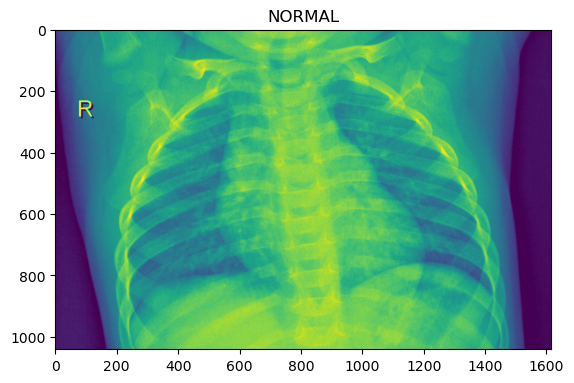

In [42]:
img=mpimg.imread(image)
imgplot=plt.imshow(img)
plt.title(CATEGORIES[int(prediction[0][0])])
plt.show()

In [43]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [45]:
# importing necessary libraries
import os
import cv2
import numpy as np
import tensorflow as tf
from keras.models import load_model

# set the path for test data
test_dir = "C:\\Users\\Admin\\OneDrive\\Desktop\\chest_xray-20250726T110654Z-1-001\\chest_xray\\test"

# define categories
CATEGORIES = ["NORMAL", "PNEUMONIA"]

# set image size
img_size = 100

# load the saved model
model = load_model('C:\\Users\\Admin\\OneDrive\\Desktop\\chest_xray-20250726T110654Z-1-001\\chest_xray\\model_mwisho5.h5')

# initialize lists for storing test data
X_test = []
y_test = []

# loop through the test data directory and extract the images and their labels
for category in CATEGORIES:
    path = os.path.join(test_dir, category)
    class_num = CATEGORIES.index(category)
    for img in os.listdir(path):
        try:
            img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
            new_array = cv2.resize(img_array, (img_size, img_size))
            X_test.append(new_array)
            y_test.append(class_num)
        except Exception as e:
            pass

# convert test data to numpy arrays
X_test = np.array(X_test).reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)

# normalize test data
X_test = X_test / 255.0

# calculate test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

# print test accuracy
print('Test accuracy:', test_acc)


20/20 - 8s - 380ms/step - accuracy: 0.7212 - loss: 1.1400
Test accuracy: 0.7211538553237915


## Pre-Trained Models

In [46]:
# import necessary libraries
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# define image size
img_size = 100

# load the pre-trained model (VGG16)
base_model = VGG16(input_shape=(img_size,img_size,3), include_top=False, weights='imagenet')

# freeze the layers of the pre-trained model
for layer in base_model.layers:
    layer.trainable = False

# add custom layers for classification
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

# create a new model
model = Model(inputs=base_model.input, outputs=predictions)

# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# define the image generators for training and validation data
train_datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

# specify the training and validation data directories
train_dir = 'C:\\Users\\Admin\\OneDrive\\Desktop\\chest_xray-20250726T110654Z-1-001\\chest_xray\\train'
val_dir = 'C:\\Users\\Admin\\OneDrive\\Desktop\\chest_xray-20250726T110654Z-1-001\\chest_xray\\val'

# create the image generators for training and validation data
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary')

# train the model
model.fit(train_generator, epochs=10, validation_data=val_generator)

# evaluate the model on test data
test_dir = 'C:\\Users\\Admin\\OneDrive\\Desktop\\chest_xray-20250726T110654Z-1-001\\chest_xray\\test'
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary', shuffle=False)
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)


Found 5226 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 523s 3s/step - accuracy: 0.9059 - loss: 0.2276 - val_accuracy: 0.8750 - val_loss: 0.2153
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.9443 - loss: 0.1542 - val_accuracy: 0.7500 - val_loss: 0.5810
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 399s 2s/step - accuracy: 0.9524 - loss: 0.1344 - val_accuracy: 0.8750 - val_loss: 0.2306
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.9508 - loss: 0.1275 - val_accuracy: 0.9375 - val_loss: 0.2436
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.9525 - loss: 0.1246 - val_accuracy: 0.8750 - val_loss: 0.2683
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 388s 2s/step - accuracy: 0.9539 - loss: 0.1256 - val_accuracy: 0.7500 - val_loss: 0.3719
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.9552 - loss: 0.1206 - val_accuracy: 0.8750 - val_loss: 0.2573
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 449s 2s/step - accuracy: 0.9558 - loss: 0.1187 - val_accu

In [50]:
# saving the pre-trained model
model.save(r"C:\\Users\\Admin\\OneDrive\\Desktop\\chest_xray-20250726T110654Z-1-001\\chest_xray\\custom_pre_trained_model_mwisho5.h5")

In [51]:
model = tf.keras.models.load_model("C:\\Users\\Admin\\OneDrive\\Desktop\\chest_xray-20250726T110654Z-1-001\\chest_xray\\custom_pre_trained_model_mwisho5.h5")

In [52]:
model.summary()

Model: "functional_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 100, 100, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 100, 100, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 50, 50, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 50, 50, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 50, 50, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 25, 25, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 25, 25, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 25, 25, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 25, 25, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 12, 12, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 15,935,811 (60.79 MB)

 Trainable params: 1,221,121 (4.66 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2 (12.00 B)

In [53]:
# evaluate the model on test data
test_dir = 'C:\\Users\\Admin\\OneDrive\\Desktop\\chest_xray-20250726T110654Z-1-001\\chest_xray\\test'
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(img_size, img_size), batch_size=32, class_mode='binary', shuffle=False)
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.8958 - loss: 0.3151
Test accuracy: 0.8958333134651184
